In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat

In [26]:
df = pd.read_excel("data/rad_peaks.xlsx")
df = df.iloc[4:,:]
df.columns = ["Name", "n_A", "sigma", "Energie eV"]
df.dropna(inplace=True)

x = df["Energie eV"].astype(float)
y = df["n_A"].astype(float)
yerr = df["sigma"].astype(float)

In [27]:
# 2. Linearer Fit mit Kovarianzmatrix
coeffs, cov = np.polyfit(x, y, 1, cov=True)
m, c = coeffs
dm, dc = np.sqrt(np.diag(cov)) # Standardfehler (Wurzel der Varianz)

m_u = ufloat(m, dm)
c_u = ufloat(c, dc)

# 3. Text-Ausgabe der Ergebnisse
print("-" * 30)
print(f"Fit-Ergebnisse:")
print(f"Steigung m: {m_u:.2u}")
print(f"Achsenabschnitt c: {c_u:.2u}")
print("-" * 30)

------------------------------
Fit-Ergebnisse:
Steigung m: 0.34679+/-0.00042
Achsenabschnitt c: 14.13+/-0.61
------------------------------


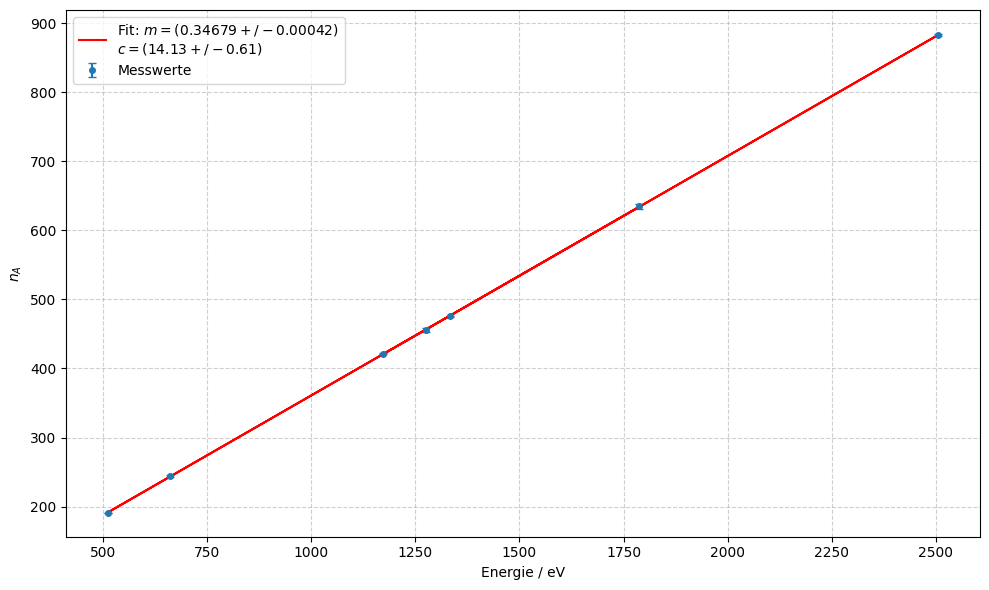

In [28]:
# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=3, label="Messwerte", markersize=4)
ax.plot(x, m*x + c, color='red', 
        label=rf"Fit: $m = ({m_u:.2u})$" + "\n" + rf"$c = ({c_u:.2u})$")

ax.set_xlabel("Energie / eV")
ax.set_ylabel("$n_A$")
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()